In [1]:
!pip install timm torch torchvision torch-geometric einops grad-cam gradio kagglehub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 88.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 84.5 MB/s eta 0:00:00


In [2]:
import kagglehub
import os, sys, math, random, cv2
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, global_mean_pool
from einops import rearrange

# ── reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ── download dataset ─────────────────────────────────────────
path = kagglehub.dataset_download("way2tutorials/diabetic-retinopathy-dataset")
print("Dataset path:", path)
print(os.listdir(path))

Device: cuda


100%|██████████| 124M/124M [00:10<00:00, 11.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/way2tutorials/diabetic-retinopathy-dataset/versions/1
['training_data_set', 'testing_dataset']


In [3]:
# ── explore folder structure ──────────────────────────────────
DATA_ROOT = Path(path)
for split in ['training_data_set', 'testing_dataset']:
    split_path = DATA_ROOT / split
    print(f"\n📁 {split}/")
    for item in sorted(split_path.iterdir()):
        if item.is_dir():
            count = len(list(item.glob("*")))
            print(f"   └── {item.name}/  ({count} files)")
        else:
            print(f"   └── {item.name}")


📁 training_data_set/
   └── training_data_set/  (5 files)

📁 testing_dataset/
   └── testing_dataset/  (5 files)


In [6]:
# ── recursively find all images ───────────────────────────────
def find_images(root):
    exts = ['*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG']
    imgs = []
    for ext in exts:
        imgs.extend(root.rglob(ext))
    return imgs

print("📁 TRAIN structure (recursive):")
for d in sorted(TRAIN_ROOT.iterdir()):
    if d.is_dir():
        imgs = find_images(d)
        sub = sorted(d.iterdir())
        print(f"  {d.name}/  → {len(imgs)} images")
        for s in sub[:3]:
            print(f"    └── {s.name}/  ({len(find_images(s))} imgs)" if s.is_dir() else f"    └── {s.name}")

print("\n📁 TEST structure (recursive):")
for d in sorted(TEST_ROOT.iterdir()):
    if d.is_dir():
        imgs = find_images(d)
        print(f"  {d.name}/  → {len(imgs)} images")
        for s in sorted(d.iterdir())[:3]:
            print(f"    └── {s.name}/  ({len(find_images(s))} imgs)" if s.is_dir() else f"    └── {s.name}")

# ── also show a raw listing of TRAIN_ROOT ─────────────────────
print("\nRaw TRAIN_ROOT listing:")
for item in sorted(TRAIN_ROOT.iterdir()):
    print(f"  {item.name}  (dir={item.is_dir()})")

📁 TRAIN structure (recursive):
  0/  → 500 images
    └── 10173_left.jpeg
    └── 10173_right.jpeg
    └── 10220_right.jpeg
  1/  → 500 images
    └── 10030_left.jpeg
    └── 10030_right.jpeg
    └── 10085_left.jpeg
  2/  → 500 images
    └── 10131_left.jpeg
    └── 10131_right.jpeg
    └── 10306_right.jpeg
  3/  → 500 images
    └── 1002_left.jpeg
    └── 10047_left.jpeg
    └── 1008_left.jpeg
  4/  → 500 images
    └── 10017_left.jpeg
    └── 10017_right.jpeg
    └── 10047_right.jpeg

📁 TEST structure (recursive):
  0/  → 100 images
    └── 10223_left.jpeg
    └── 10223_right.jpeg
    └── 10636_left.jpeg
  1/  → 100 images
    └── 10545_right.jpeg
    └── 10996_right.jpeg
    └── 11421_right.jpeg
  2/  → 100 images
    └── 10131_right.jpeg
    └── 10319_right.jpeg
    └── 10379_left.jpeg
  3/  → 96 images
    └── 10159_right.jpeg
    └── 10579_right.jpeg
    └── 10606_left.jpeg
  4/  → 100 images
    └── 1084_left.jpeg
    └── 1084_right.jpeg
    └── 1099_right.jpeg

Raw TRAIN_ROOT l

Class → Index mapping:
   Folder '0' → Grade 0: No DR
   Folder '1' → Grade 1: Mild DR
   Folder '2' → Grade 2: Moderate DR
   Folder '3' → Grade 3: Severe DR
   Folder '4' → Grade 4: Proliferative DR


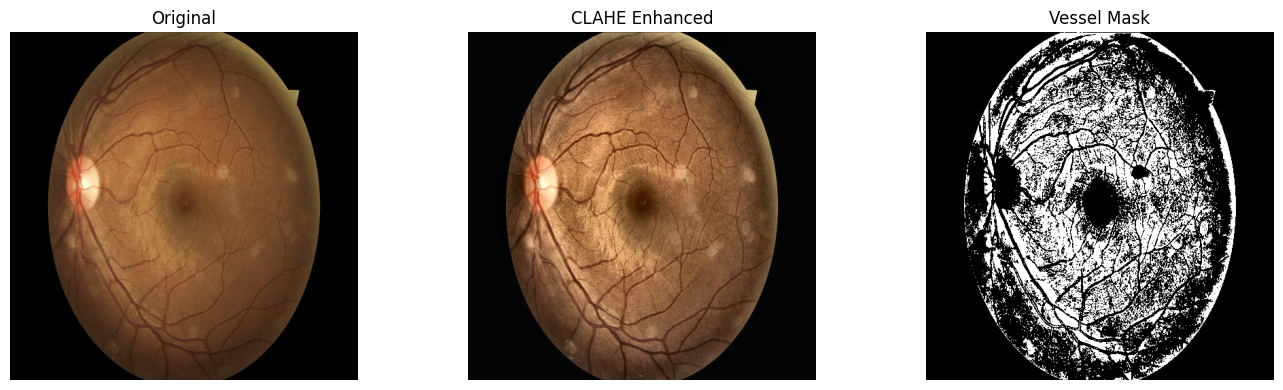


✅ Graph: 64 nodes, 320 edges
   Node feature shape: torch.Size([64, 2])
   Edge index shape:   torch.Size([2, 320])


In [7]:
# ── rebuild class map from numeric folders ────────────────────
CLASS_NAMES = ['No DR', 'Mild DR', 'Moderate DR', 'Severe DR', 'Proliferative DR']
CLASS_TO_IDX = {str(i): i for i in range(5)}
NUM_CLASSES  = 5

print("Class → Index mapping:")
for k, v in CLASS_TO_IDX.items():
    print(f"   Folder '{k}' → Grade {v}: {CLASS_NAMES[v]}")

# ── CLAHE contrast enhancement ────────────────────────────────
def apply_clahe(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    merged = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

# ── vessel segmentation via green channel ─────────────────────
def segment_vessels(img_bgr):
    green = img_bgr[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    green_eq = clahe.apply(green)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    tophat = cv2.morphologyEx(green_eq, cv2.MORPH_TOPHAT, kernel)
    _, vessel_mask = cv2.threshold(tophat, 10, 255,
                                   cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return vessel_mask

# ── junction extraction ───────────────────────────────────────
def extract_junctions(vessel_mask, max_points=64):
    vessel_f = vessel_mask.astype(np.float32)
    corners  = cv2.cornerHarris(vessel_f, blockSize=5, ksize=3, k=0.04)
    corners  = cv2.dilate(corners, None)
    threshold = 0.01 * corners.max()
    ys, xs   = np.where(corners > threshold)
    pts = list(zip(xs.tolist(), ys.tolist()))
    if len(pts) > max_points:
        idx = np.random.choice(len(pts), max_points, replace=False)
        pts = [pts[i] for i in idx]
    while len(pts) < max_points:
        pts.append((0, 0))
    return pts[:max_points]

# ── build k-NN vessel graph ───────────────────────────────────
def build_vessel_graph(junctions, img_size=512, k_neighbors=5):
    pts = np.array(junctions, dtype=np.float32) / img_size
    N   = len(pts)
    x   = torch.tensor(pts, dtype=torch.float)
    edge_list = []
    for i in range(N):
        dists      = np.linalg.norm(pts - pts[i], axis=1)
        dists[i]   = 1e9
        neighbors  = np.argsort(dists)[:k_neighbors]
        for j in neighbors:
            edge_list.append([i, j])
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return Data(x=x, edge_index=edge_index)

# ── visual check on one sample ────────────────────────────────
sample_path = sorted((TRAIN_ROOT / '0').glob("*.jpeg"))[0]
img_bgr     = cv2.imread(str(sample_path))
img_bgr     = cv2.resize(img_bgr, (512, 512))

clahe_img   = apply_clahe(img_bgr)
vessel_map  = segment_vessels(clahe_img)
junctions   = extract_junctions(vessel_map)
graph_data  = build_vessel_graph(junctions)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cv2.cvtColor(img_bgr,   cv2.COLOR_BGR2RGB)); axes[0].set_title("Original")
axes[1].imshow(cv2.cvtColor(clahe_img, cv2.COLOR_BGR2RGB)); axes[1].set_title("CLAHE Enhanced")
axes[2].imshow(vessel_map, cmap='gray');                    axes[2].set_title("Vessel Mask")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

print(f"\n✅ Graph: {graph_data.num_nodes} nodes, {graph_data.num_edges} edges")
print(f"   Node feature shape: {graph_data.x.shape}")
print(f"   Edge index shape:   {graph_data.edge_index.shape}")

In [8]:
IMG_SIZE   = 512
BATCH_SIZE = 8

# ── augmentation transforms ───────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ── Dataset ───────────────────────────────────────────────────
class DRDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples   = []
        self.transform = transform
        for grade in range(5):
            folder = Path(root) / str(grade)
            for fp in sorted(folder.glob("*.jpeg")):
                self.samples.append((fp, grade))
        print(f"  Loaded {len(self.samples)} samples from {root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fp, label = self.samples[idx]

        # ── CNN / Transformer input ───────────────────────────
        img_bgr  = cv2.imread(str(fp))
        img_bgr  = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
        img_clahe = apply_clahe(img_bgr)
        img_rgb  = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)
        img_pil  = Image.fromarray(img_rgb)
        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = transforms.ToTensor()(img_pil)

        # ── GNN input ─────────────────────────────────────────
        vessel_map  = segment_vessels(img_clahe)
        junctions   = extract_junctions(vessel_map)
        graph       = build_vessel_graph(junctions)

        return img_tensor, graph, label

# ── collate: images stack normally, graphs batch via PyG ──────
def collate_fn(batch):
    imgs, graphs, labels = zip(*batch)
    imgs   = torch.stack(imgs)
    graphs = Batch.from_data_list(list(graphs))
    labels = torch.tensor(labels, dtype=torch.long)
    return imgs, graphs, labels

# ── create loaders ────────────────────────────────────────────
print("Building datasets...")
train_ds = DRDataset(TRAIN_ROOT, transform=train_tf)
test_ds  = DRDataset(TEST_ROOT,  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)

print(f"\n✅ Train batches: {len(train_loader)}")
print(f"✅ Test  batches: {len(test_loader)}")

# ── sanity check one batch ────────────────────────────────────
imgs, graphs, labels = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  imgs:        {imgs.shape}")
print(f"  graph nodes: {graphs.x.shape}")
print(f"  graph edges: {graphs.edge_index.shape}")
print(f"  labels:      {labels}")

Building datasets...
  Loaded 2500 samples from /root/.cache/kagglehub/datasets/way2tutorials/diabetic-retinopathy-dataset/versions/1/training_data_set/training_data_set
  Loaded 496 samples from /root/.cache/kagglehub/datasets/way2tutorials/diabetic-retinopathy-dataset/versions/1/testing_dataset/testing_dataset

✅ Train batches: 313
✅ Test  batches: 62

Batch shapes:
  imgs:        torch.Size([8, 3, 512, 512])
  graph nodes: torch.Size([512, 2])
  graph edges: torch.Size([2, 2560])
  labels:      tensor([2, 3, 4, 0, 1, 1, 0, 4])


In [10]:
class CNNBranch(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b4', pretrained=True, features_only=True,
            out_indices=(1, 2, 3, 4)
        )
        # ── auto-detect actual channel sizes ──────────────────
        with torch.no_grad():
            dummy   = torch.zeros(1, 3, 512, 512)
            feats   = self.backbone(dummy)
            in_channels = [f.shape[1] for f in feats]
        print(f"   EfficientNet-B4 feature channels: {in_channels}")

        fpn_out = 256
        self.lat = nn.ModuleList([
            nn.Conv2d(c, fpn_out, 1) for c in in_channels
        ])
        self.out_conv = nn.ModuleList([
            nn.Conv2d(fpn_out, fpn_out, 3, padding=1) for _ in in_channels
        ])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fpn_out, out_dim),
            nn.GELU()
        )

    def forward(self, x):
        feats     = self.backbone(x)
        lat_feats = [l(f) for l, f in zip(self.lat, feats)]

        # top-down FPN
        fpn_feats = [lat_feats[-1]]
        for i in range(len(lat_feats) - 2, -1, -1):
            up = F.interpolate(fpn_feats[-1], size=lat_feats[i].shape[-2:],
                               mode='nearest')
            fpn_feats.append(lat_feats[i] + up)
        fpn_feats = fpn_feats[::-1]

        out = self.out_conv[0](fpn_feats[0])
        out = self.pool(out)
        return self.proj(out)                      # [B, out_dim]

# ── test ──────────────────────────────────────────────────────
cnn = CNNBranch(out_dim=256).to(DEVICE)
dummy_img = torch.randn(2, 3, 512, 512).to(DEVICE)
with torch.no_grad():
    cnn_out = cnn(dummy_img)
print(f"✅ CNN branch output: {cnn_out.shape}")    # expect [2, 256]

   EfficientNet-B4 feature channels: [32, 56, 160, 448]
✅ CNN branch output: torch.Size([2, 256])


In [11]:
# ════════════════════════════════════════════════════════════
#  GNN Branch  —  Graph Attention Network on vessel graph
# ════════════════════════════════════════════════════════════
class GNNBranch(nn.Module):
    def __init__(self, in_dim=2, hidden=64, out_dim=256, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_dim,         hidden,  heads=heads, dropout=0.1)
        self.conv2 = GATConv(hidden * heads, hidden,  heads=heads, dropout=0.1)
        self.conv3 = GATConv(hidden * heads, out_dim, heads=1,
                             concat=False,            dropout=0.1)
        self.norm1 = nn.LayerNorm(hidden * heads)
        self.norm2 = nn.LayerNorm(hidden * heads)
        self.proj  = nn.Sequential(nn.Linear(out_dim, out_dim), nn.GELU())

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.gelu(self.norm1(self.conv1(x, edge_index)))
        x = F.gelu(self.norm2(self.conv2(x, edge_index)))
        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)             # [B, out_dim]
        return self.proj(x)

# ════════════════════════════════════════════════════════════
#  Transformer Branch  —  ViT-style patch attention
# ════════════════════════════════════════════════════════════
class TransformerBranch(nn.Module):
    def __init__(self, img_size=512, patch_size=32, in_ch=3,
                 embed_dim=512, depth=6, n_heads=8, out_dim=512):
        super().__init__()
        self.patch_size  = patch_size
        n_patches        = (img_size // patch_size) ** 2   # 256

        self.patch_embed = nn.Conv2d(in_ch, embed_dim,
                                     kernel_size=patch_size,
                                     stride=patch_size)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm        = nn.LayerNorm(embed_dim)
        self.proj        = nn.Sequential(nn.Linear(embed_dim, out_dim), nn.GELU())

    def forward(self, x):
        B = x.shape[0]
        x   = self.patch_embed(x)
        x   = rearrange(x, 'b c h w -> b (h w) c')
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed
        x   = self.transformer(x)
        x   = self.norm(x)
        return self.proj(x[:, 0])                  # [B, out_dim]

# ── quick tests ───────────────────────────────────────────────
gnn = GNNBranch(out_dim=256).to(DEVICE)
vit = TransformerBranch(out_dim=512).to(DEVICE)

# build 2 dummy graphs from real images
sample_imgs = sorted((TRAIN_ROOT / '0').glob('*.jpeg'))[:2]
dummy_graphs = []
for sp in sample_imgs:
    img = cv2.resize(cv2.imread(str(sp)), (512, 512))
    vm  = segment_vessels(apply_clahe(img))
    jn  = extract_junctions(vm)
    dummy_graphs.append(build_vessel_graph(jn))
dummy_graph_batch = Batch.from_data_list(dummy_graphs).to(DEVICE)

with torch.no_grad():
    gnn_out = gnn(dummy_graph_batch)
    vit_out = vit(dummy_img)

print(f"✅ GNN branch output:         {gnn_out.shape}")   # [2, 256]
print(f"✅ Transformer branch output: {vit_out.shape}")   # [2, 512]

✅ GNN branch output:         torch.Size([2, 256])
✅ Transformer branch output: torch.Size([2, 512])


In [12]:
class BidirectionalCrossAttentionBridge(nn.Module):
    """
    GNN global embed  ↔  Transformer CLS token talk to each other.
    Each acts as Query against the other's Key/Value.
    Output: refined gnn_embed (256) and vit_embed (512).
    """
    def __init__(self, gnn_dim=256, vit_dim=512, n_heads=8, dropout=0.1):
        super().__init__()
        # project both to common dim for attention
        common = 256
        self.gnn_proj = nn.Linear(gnn_dim, common)
        self.vit_proj = nn.Linear(vit_dim,  common)

        # GNN queries Transformer
        self.gnn_queries_vit = nn.MultiheadAttention(
            embed_dim=common, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        # Transformer queries GNN
        self.vit_queries_gnn = nn.MultiheadAttention(
            embed_dim=common, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )

        # project back to original dims
        self.gnn_back = nn.Sequential(
            nn.Linear(common, gnn_dim), nn.GELU(),
            nn.LayerNorm(gnn_dim)
        )
        self.vit_back = nn.Sequential(
            nn.Linear(common, vit_dim), nn.GELU(),
            nn.LayerNorm(vit_dim)
        )

        self.norm_gnn = nn.LayerNorm(common)
        self.norm_vit = nn.LayerNorm(common)

    def forward(self, gnn_embed, vit_embed):
        # gnn_embed: [B, 256]   vit_embed: [B, 512]
        # unsqueeze seq dim for MHA: [B, 1, dim]
        g = self.gnn_proj(gnn_embed).unsqueeze(1)   # [B, 1, common]
        v = self.vit_proj(vit_embed).unsqueeze(1)   # [B, 1, common]

        # GNN attends to Transformer
        g_att, _ = self.gnn_queries_vit(query=g, key=v, value=v)
        g_out    = self.norm_gnn(g + g_att).squeeze(1)   # residual + [B, common]

        # Transformer attends to GNN
        v_att, _ = self.vit_queries_gnn(query=v, key=g, value=g)
        v_out    = self.norm_vit(v + v_att).squeeze(1)   # [B, common]

        return self.gnn_back(g_out), self.vit_back(v_out)  # [B,256], [B,512]

# ── test ──────────────────────────────────────────────────────
bridge = BidirectionalCrossAttentionBridge().to(DEVICE)
with torch.no_grad():
    g_ref, v_ref = bridge(gnn_out, vit_out)
print(f"✅ Bridge → GNN refined: {g_ref.shape}")   # [2, 256]
print(f"✅ Bridge → ViT refined: {v_ref.shape}")   # [2, 512]

✅ Bridge → GNN refined: torch.Size([2, 256])
✅ Bridge → ViT refined: torch.Size([2, 512])


In [13]:
class ReGraNet(nn.Module):
    """
    ReGraNet — Retinal Graph Reasoning Network
    CNN (256) + GNN (256) + Transformer (512)
    → Cross-Attention Bridge (GNN ↔ Transformer)
    → Fusion MLP: 1024 → 512 → num_classes
    """
    def __init__(self, num_classes=5):
        super().__init__()
        self.cnn     = CNNBranch(out_dim=256)
        self.gnn     = GNNBranch(out_dim=256)
        self.vit     = TransformerBranch(out_dim=512)
        self.bridge  = BidirectionalCrossAttentionBridge(
                           gnn_dim=256, vit_dim=512)

        # fusion: 256 + 256 + 512 = 1024
        self.fusion = nn.Sequential(
            nn.Linear(1024, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, graph):
        # three parallel branches
        cnn_feat = self.cnn(img)          # [B, 256]
        gnn_feat = self.gnn(graph)        # [B, 256]
        vit_feat = self.vit(img)          # [B, 512]

        # bidirectional cross-attention (GNN ↔ Transformer)
        gnn_feat, vit_feat = self.bridge(gnn_feat, vit_feat)

        # concat → MLP fusion head
        fused = torch.cat([cnn_feat, gnn_feat, vit_feat], dim=1)  # [B,1024]
        return self.fusion(fused)         # [B, num_classes]

# ── build model + parameter count ────────────────────────────
model = ReGraNet(num_classes=5).to(DEVICE)

total  = sum(p.numel() for p in model.parameters())
train_ = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ ReGraNet built successfully")
print(f"   Total params:     {total/1e6:.2f}M")
print(f"   Trainable params: {train_/1e6:.2f}M")

# ── full forward pass test ────────────────────────────────────
imgs, graphs, labels = next(iter(train_loader))
imgs   = imgs.to(DEVICE)
graphs = graphs.to(DEVICE)

with torch.no_grad():
    logits = model(imgs, graphs)
print(f"   Forward pass output: {logits.shape}")  # [8, 5]
print(f"   Sample logits: {logits[0].cpu().numpy().round(3)}")

   EfficientNet-B4 feature channels: [32, 56, 160, 448]
✅ ReGraNet built successfully
   Total params:     42.01M
   Trainable params: 42.01M
   Forward pass output: torch.Size([8, 5])
   Sample logits: [-0.048  0.048 -0.096  0.105  0.164]


In [15]:
# ── class weights (handle imbalance) ─────────────────────────
from sklearn.utils.class_weight import compute_class_weight

all_labels = [s[1] for s in train_ds.samples]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=all_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print("Class weights:", class_weights.cpu().numpy().round(3))

# ── loss ──────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# ── optimizer: separate LRs for backbone vs new heads ─────────
backbone_params = list(model.cnn.backbone.parameters())
new_params      = [p for p in model.parameters()
                   if not any(p is bp for bp in backbone_params)]

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 1e-4, 'weight_decay': 1e-4},
    {'params': new_params,      'lr': 3e-4, 'weight_decay': 1e-4},
])

# ── cosine annealing with warm restarts ───────────────────────
NUM_EPOCHS = 20
scheduler  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-6
)

# ── mixed precision scaler ────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print(f"✅ Optimizer ready  — backbone lr=1e-4, heads lr=3e-4")
print(f"✅ Scheduler: CosineAnnealingWarmRestarts T_0=10")
print(f"✅ Loss: CrossEntropy + label_smoothing=0.1 + class weights")
print(f"✅ Mixed precision: {torch.cuda.is_available()}")

Class weights: [1. 1. 1. 1. 1.]
✅ Optimizer ready  — backbone lr=1e-4, heads lr=3e-4
✅ Scheduler: CosineAnnealingWarmRestarts T_0=10
✅ Loss: CrossEntropy + label_smoothing=0.1 + class weights
✅ Mixed precision: True


/tmp/ipykernel_584/2595415853.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [16]:
from sklearn.metrics import cohen_kappa_score, classification_report
import time

# ── metric helpers ────────────────────────────────────────────
def accuracy(logits, labels):
    return (logits.argmax(1) == labels).float().mean().item()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_acc = 0., 0.
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch_idx, (imgs, graphs, labels) in enumerate(loader):
            imgs   = imgs.to(DEVICE, non_blocking=True)
            graphs = graphs.to(DEVICE)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(imgs, graphs)
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()
            total_acc  += accuracy(logits, labels)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if train and (batch_idx + 1) % 50 == 0:
                print(f"   step {batch_idx+1}/{len(loader)} "
                      f"loss={loss.item():.4f}")

    n     = len(loader)
    kappa = cohen_kappa_score(all_labels, all_preds,
                              weights='quadratic',
                              labels=list(range(NUM_CLASSES)))
    return total_loss / n, total_acc / n, kappa

# ── training loop ─────────────────────────────────────────────
history = {'train_loss':[], 'val_loss':[],
           'train_acc':[],  'val_acc':[],
           'train_kappa':[],'val_kappa':[]}

best_kappa = 0.0
best_epoch = 0

print("🚀 Starting ReGraNet training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc, tr_kappa = run_epoch(train_loader, train=True)
    vl_loss, vl_acc, vl_kappa = run_epoch(test_loader,  train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['train_kappa'].append(tr_kappa)
    history['val_kappa'].append(vl_kappa)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss={tr_loss:.4f} acc={tr_acc:.4f} κ={tr_kappa:.4f} | "
          f"Val loss={vl_loss:.4f} acc={vl_acc:.4f} κ={vl_kappa:.4f} | "
          f"{elapsed:.0f}s")

    # ── save best checkpoint ──────────────────────────────────
    if vl_kappa > best_kappa:
        best_kappa = vl_kappa
        best_epoch = epoch
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_kappa':   vl_kappa,
            'val_acc':     vl_acc,
        }, 'regranet_best.pth')
        print(f"   💾 Saved best model  (κ={best_kappa:.4f})")

print(f"\n✅ Training complete. Best val κ={best_kappa:.4f} at epoch {best_epoch}")

🚀 Starting ReGraNet training...



/tmp/ipykernel_584/965797215.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


   step 50/313 loss=1.0857
   step 100/313 loss=1.1141
   step 150/313 loss=1.6140
   step 200/313 loss=1.4104
   step 250/313 loss=0.9302
   step 300/313 loss=0.9726


/tmp/ipykernel_584/965797215.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 01/20 | Train loss=1.2341 acc=0.5100 κ=0.6454 | Val loss=1.2579 acc=0.5101 κ=0.7466 | 237s
   💾 Saved best model  (κ=0.7466)


...

Epoch 19/20 | Train loss=0.6333 acc=0.8894 κ=0.9473 | Val loss=0.5881 acc=0.9113 κ=0.9654 | 206s
   💾 Saved best model  (κ=0.9654)


/tmp/ipykernel_584/965797215.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


   step 50/313 loss=0.9001
   step 100/313 loss=0.4261
   step 150/313 loss=0.7433
   step 200/313 loss=0.4985
   step 250/313 loss=0.5453
   step 300/313 loss=0.8158


/tmp/ipykernel_584/965797215.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 20/20 | Train loss=0.6092 acc=0.8978 κ=0.9524 | Val loss=0.5666 acc=0.9133 κ=0.9718 | 205s
   💾 Saved best model  (κ=0.9718)

✅ Training complete. Best val κ=0.9718 at epoch 20


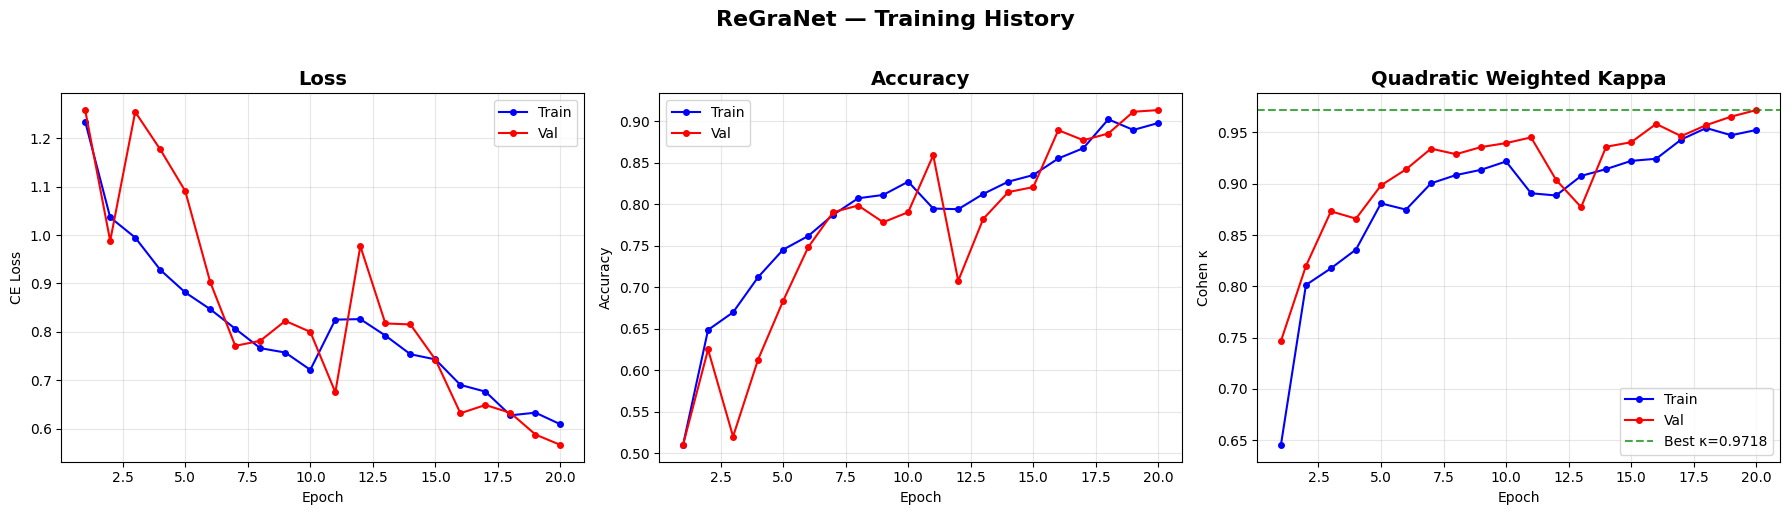

✅ Training curves saved.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, NUM_EPOCHS + 1)

# loss
axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train')
axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# accuracy
axes[1].plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Train')
axes[1].plot(epochs, history['val_acc'],   'r-o', markersize=4, label='Val')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

# quadratic kappa
axes[2].plot(epochs, history['train_kappa'], 'b-o', markersize=4, label='Train')
axes[2].plot(epochs, history['val_kappa'],   'r-o', markersize=4, label='Val')
axes[2].axhline(y=0.9718, color='green', linestyle='--', alpha=0.7, label=f'Best κ=0.9718')
axes[2].set_title('Quadratic Weighted Kappa', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Cohen κ')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('ReGraNet — Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('regranet_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved.")

✅ Loaded best model — epoch 20  κ=0.9718


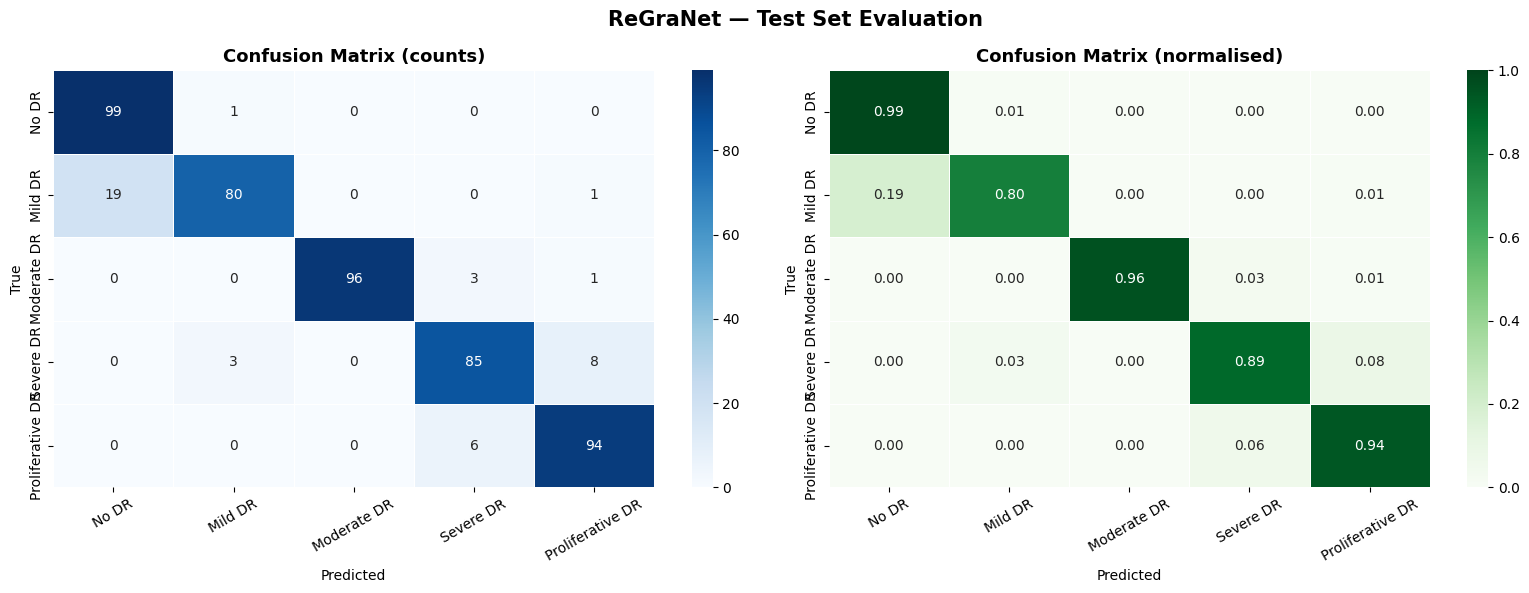


📊 Classification Report:
                  precision    recall  f1-score   support

           No DR     0.8390    0.9900    0.9083       100
         Mild DR     0.9524    0.8000    0.8696       100
     Moderate DR     1.0000    0.9600    0.9796       100
       Severe DR     0.9043    0.8854    0.8947        96
Proliferative DR     0.9038    0.9400    0.9216       100

        accuracy                         0.9153       496
       macro avg     0.9199    0.9151    0.9147       496
    weighted avg     0.9200    0.9153    0.9149       496

  Final Test Accuracy       : 0.9153  (91.53%)
  Final Quadratic Kappa (κ) : 0.9699


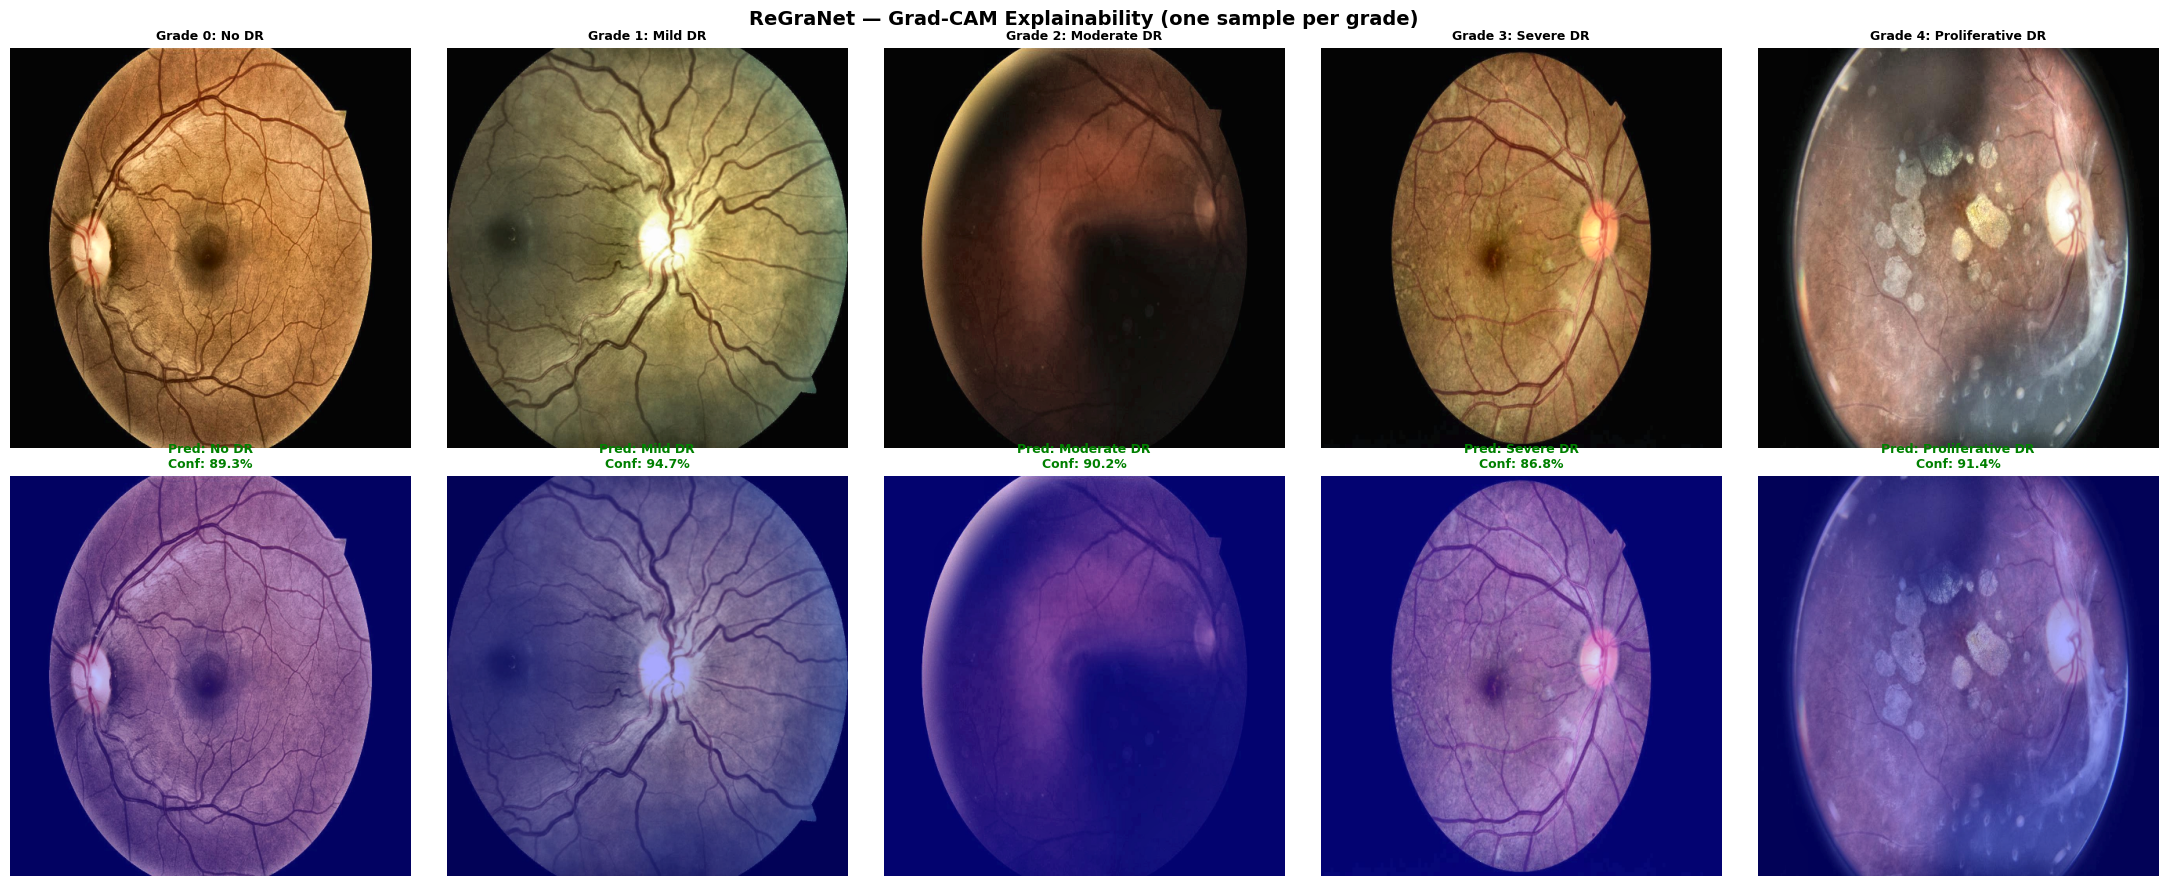

✅ Grad-CAM saved.

📦 Files ready:
   regranet_weights.pth  (168.86 MB)
   regranet_results.pkl  (0.02 MB)
   regranet_confusion_matrix.png  (0.12 MB)
   regranet_gradcam.png  (4.07 MB)
   regranet_training_curves.png  (0.17 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score
import seaborn as sns
import numpy as np, torch, torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import pickle, os
from google.colab import files

# ══════════════════════════════════════════════════════════════
# 1. LOAD BEST CHECKPOINT  (weights_only=False for PyTorch 2.6)
# ══════════════════════════════════════════════════════════════
ckpt = torch.load('regranet_best.pth', map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f"✅ Loaded best model — epoch {ckpt['epoch']}  κ={ckpt['val_kappa']:.4f}")

# ══════════════════════════════════════════════════════════════
# 2. FULL TEST SET INFERENCE
# ══════════════════════════════════════════════════════════════
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, graphs, labels in test_loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        graphs = graphs.to(DEVICE)
        logits = model(imgs, graphs)
        probs  = F.softmax(logits, dim=1)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ══════════════════════════════════════════════════════════════
# 3. CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalised)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('ReGraNet — Test Set Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('regranet_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════
# 4. CLASSIFICATION REPORT
# ══════════════════════════════════════════════════════════════
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=4))
final_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
final_acc   = (all_preds == all_labels).mean()
print(f"{'='*52}")
print(f"  Final Test Accuracy       : {final_acc:.4f}  ({final_acc*100:.2f}%)")
print(f"  Final Quadratic Kappa (κ) : {final_kappa:.4f}")
print(f"{'='*52}")

# ══════════════════════════════════════════════════════════════
# 5. GRAD-CAM EXPLAINABILITY
# ══════════════════════════════════════════════════════════════
# wrapper so GradCAM sees only the image (not graph)
class CNNOnly(torch.nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.full = full_model
    def forward(self, x):
        return self.full.cnn(x)          # only CNN branch for GradCAM

cnn_wrapper    = CNNOnly(model).to(DEVICE)
target_layer   = [model.cnn.out_conv[0]] # finest FPN output conv

cam = GradCAM(model=cnn_wrapper, target_layers=target_layer)

# pick one sample from each grade
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
shown = {g: False for g in range(5)}

for fp, grade in test_ds.samples:
    if shown[grade]:
        continue

    # load & preprocess
    img_bgr   = cv2.imread(str(fp))
    img_bgr   = cv2.resize(img_bgr, (512, 512))
    img_clahe = apply_clahe(img_bgr)
    img_rgb   = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)
    img_norm  = val_tf(Image.fromarray(img_rgb)).unsqueeze(0).to(DEVICE)

    # run GradCAM
    targets   = [ClassifierOutputTarget(grade)]
    grayscale = cam(input_tensor=img_norm, targets=targets)
    heatmap   = show_cam_on_image(img_rgb.astype(np.float32)/255.,
                                  grayscale[0], use_rgb=True)

    # get model prediction + confidence
    vessel_map = segment_vessels(img_clahe)
    junctions  = extract_junctions(vessel_map)
    graph      = build_vessel_graph(junctions)
    graph_b    = Batch.from_data_list([graph]).to(DEVICE)
    with torch.no_grad():
        logits = model(img_norm, graph_b)
        probs  = F.softmax(logits, dim=1)[0]
    pred_grade = logits.argmax(1).item()
    confidence = probs[pred_grade].item() * 100

    col = grade
    axes[0][col].imshow(img_rgb)
    axes[0][col].set_title(f"Grade {grade}: {CLASS_NAMES[grade]}", fontsize=9, fontweight='bold')
    axes[0][col].axis('off')

    axes[1][col].imshow(heatmap)
    pred_label = f"Pred: {CLASS_NAMES[pred_grade]}"
    color      = 'green' if pred_grade == grade else 'red'
    axes[1][col].set_title(f"{pred_label}\nConf: {confidence:.1f}%",
                            fontsize=9, color=color, fontweight='bold')
    axes[1][col].axis('off')

    shown[grade] = True
    if all(shown.values()):
        break

axes[0][0].set_ylabel("Original", fontsize=11, fontweight='bold')
axes[1][0].set_ylabel("Grad-CAM", fontsize=11, fontweight='bold')
plt.suptitle('ReGraNet — Grad-CAM Explainability (one sample per grade)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regranet_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grad-CAM saved.")

# ══════════════════════════════════════════════════════════════
# 6. SAVE MODEL WEIGHTS + HISTORY PKL
# ══════════════════════════════════════════════════════════════
# re-save checkpoint with weights_only-safe format
torch.save(model.state_dict(), 'regranet_weights.pth')

# save training history + metrics
results = {
    'history':      history,
    'final_kappa':  final_kappa,
    'final_acc':    final_acc,
    'all_preds':    all_preds,
    'all_labels':   all_labels,
    'all_probs':    all_probs,
    'class_names':  CLASS_NAMES,
    'best_epoch':   ckpt['epoch'],
    'best_kappa':   ckpt['val_kappa'],
}
with open('regranet_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("\n📦 Files ready:")
for fname in ['regranet_weights.pth', 'regranet_results.pkl',
              'regranet_confusion_matrix.png', 'regranet_gradcam.png',
              'regranet_training_curves.png']:
    size = os.path.getsize(fname) / 1e6
    print(f"   {fname}  ({size:.2f} MB)")

# ── download all ──────────────────────────────────────────────
for fname in ['regranet_weights.pth', 'regranet_results.pkl',
              'regranet_confusion_matrix.png', 'regranet_gradcam.png',
              'regranet_training_curves.png']:
    files.download(fname)

print("\n✅ All files downloaded!")

✅ Patched ViT branch ready


/tmp/ipykernel_584/1083534093.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


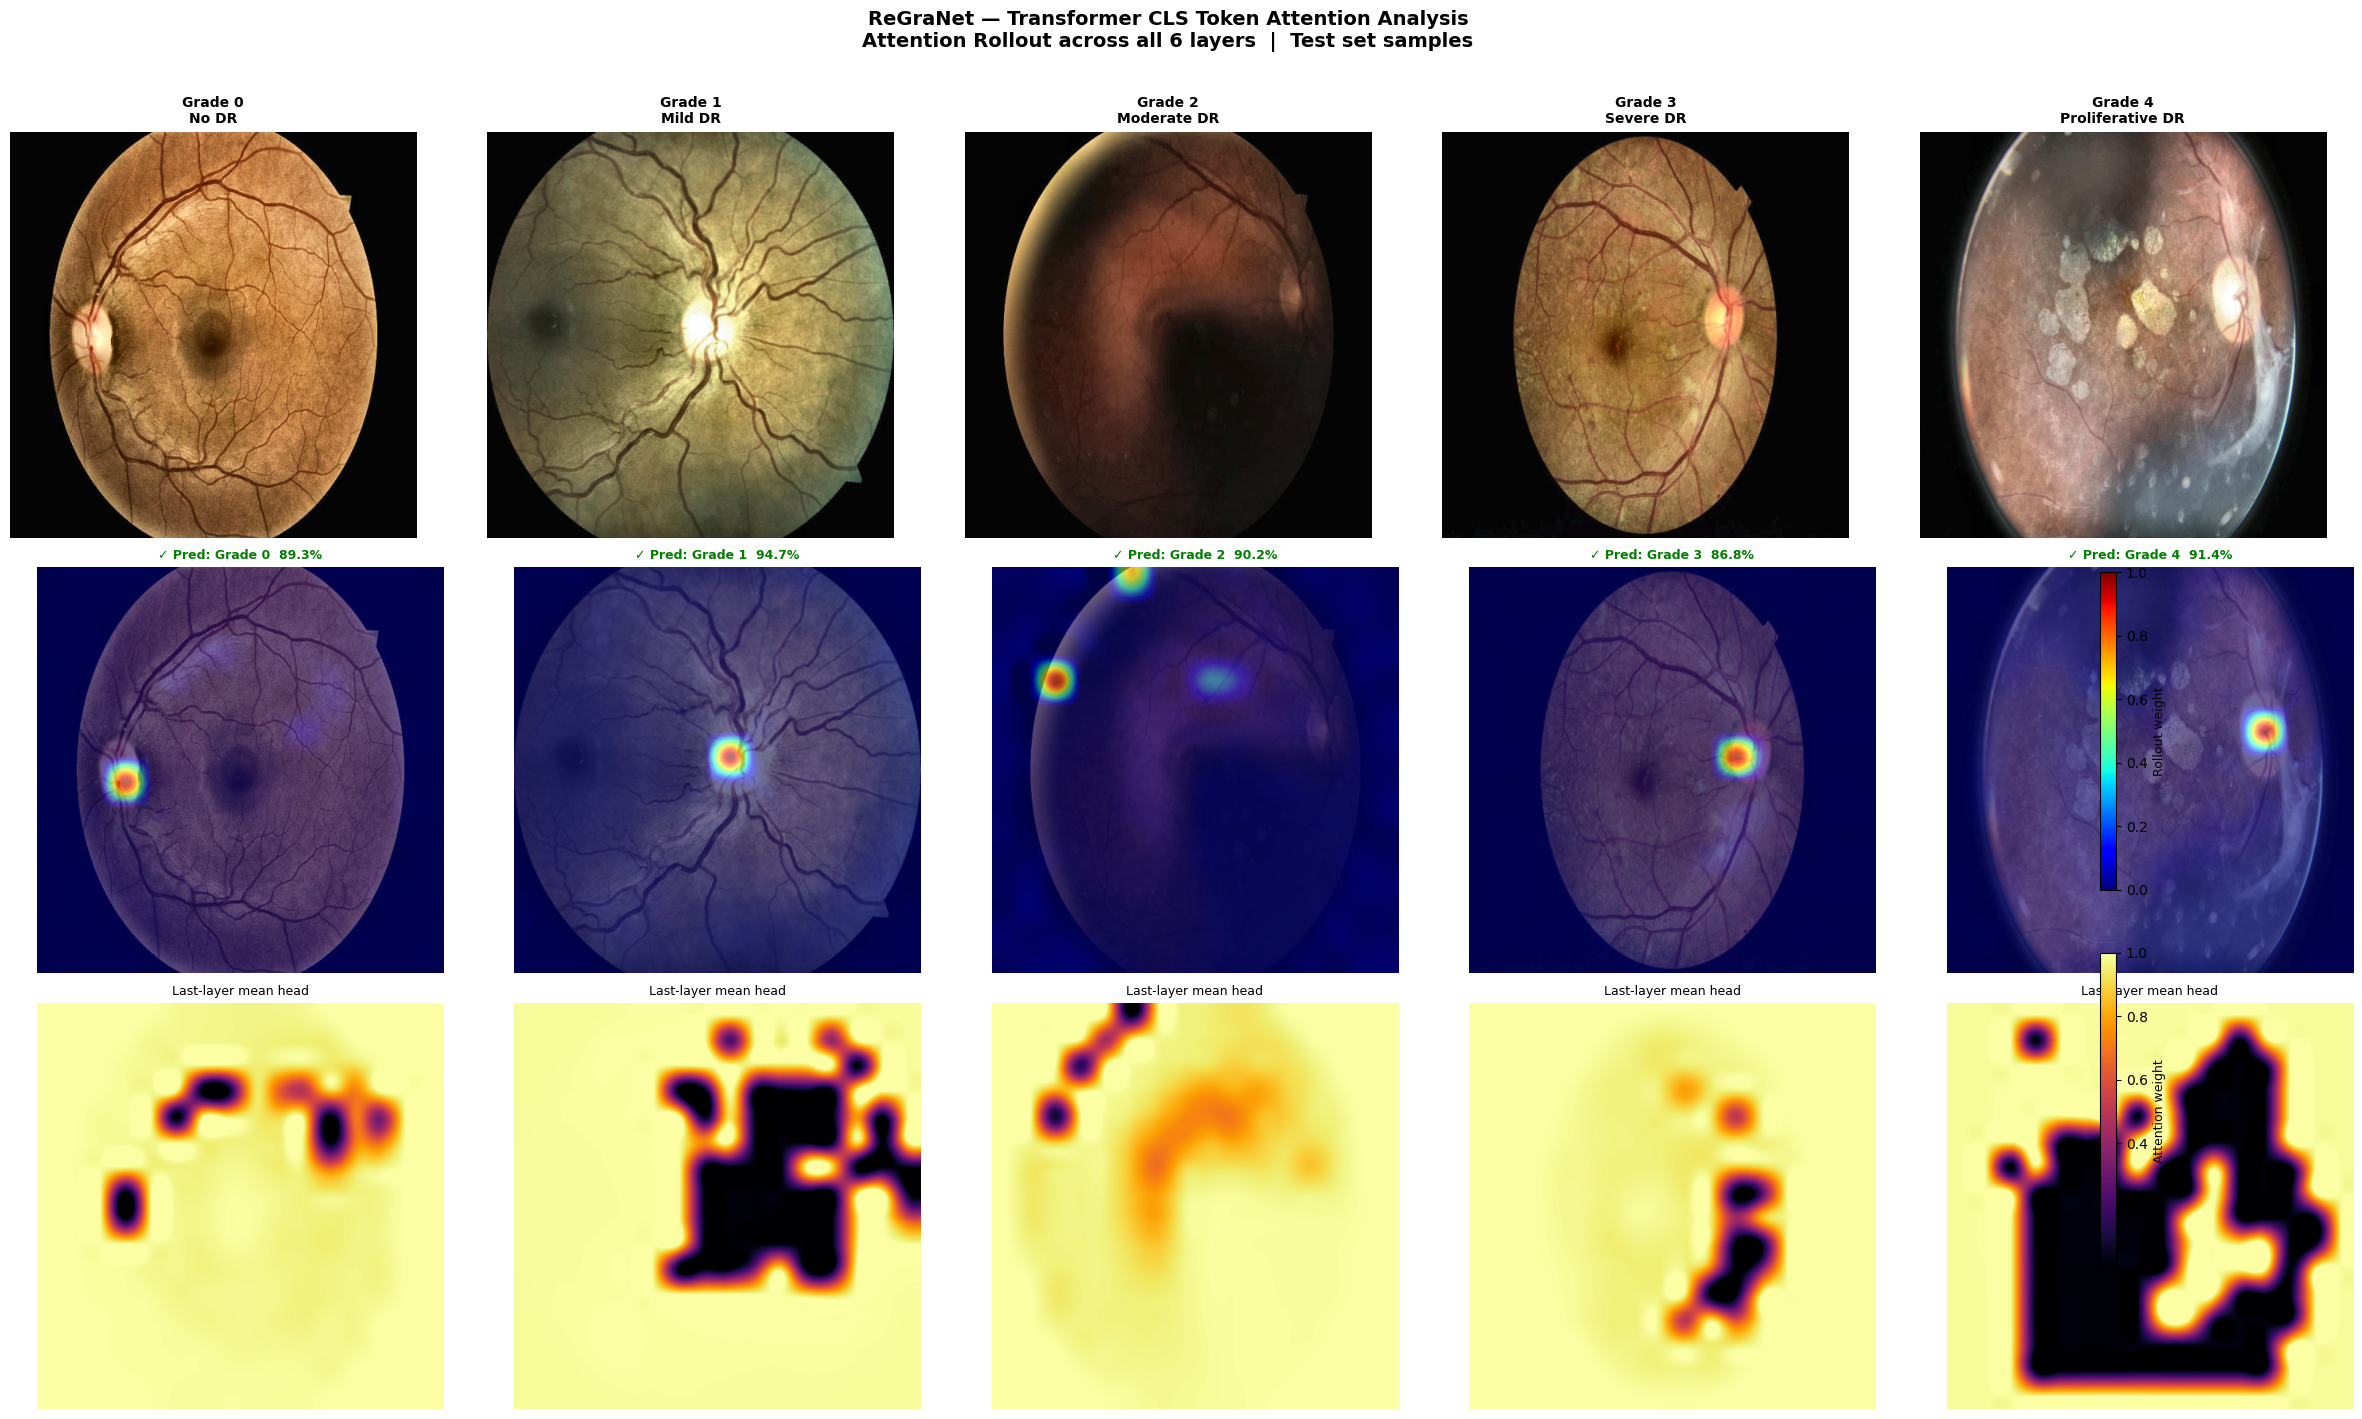

✅ Attention map figure saved → regranet_attention_maps.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ══════════════════════════════════════════════════════════════
# 1. HOOK TO EXTRACT ATTENTION WEIGHTS FROM ALL LAYERS
# ══════════════════════════════════════════════════════════════
class AttentionExtractor:
    """Registers forward hooks on every TransformerEncoderLayer
       to capture the self-attention weights."""
    def __init__(self, transformer_branch):
        self.attentions = []   # list of [B, heads, seq, seq] per layer
        self.hooks      = []
        for layer in transformer_branch.transformer.layers:
            h = layer.self_attn.register_forward_hook(self._hook)
            self.hooks.append(h)

    def _hook(self, module, input, output):
        # output = (attn_output, attn_weights)
        # attn_weights shape: [B, seq, seq]  (averaged over heads by PyTorch)
        # We need need_weights=True — patch via input
        # Re-run self_attn with need_weights=True to grab weights
        pass

    def remove(self):
        for h in self.hooks:
            h.remove()

# PyTorch's nn.MultiheadAttention only returns weights if need_weights=True
# We patch the TransformerEncoderLayer forward to capture them

class PatchedTransformerBranch(nn.Module):
    """Same as TransformerBranch but stores per-layer attention maps."""
    def __init__(self, original: TransformerBranch):
        super().__init__()
        self.patch_embed = original.patch_embed
        self.cls_token   = original.cls_token
        self.pos_embed   = original.pos_embed
        self.layers      = original.transformer.layers
        self.norm        = original.norm
        self.proj        = original.proj
        self.attn_maps   = []   # filled on each forward

    def forward(self, x):
        B = x.shape[0]
        x   = self.patch_embed(x)
        x   = rearrange(x, 'b c h w -> b (h w) c')
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        self.attn_maps = []
        for layer in self.layers:
            # self-attention with weights
            x2, attn_w = layer.self_attn(
                x, x, x,
                need_weights=True,
                average_attn_weights=False   # keep all heads → [B, H, S, S]
            )
            self.attn_maps.append(attn_w.detach().cpu())
            # rest of encoder layer manually
            x = layer.norm1(x + layer.dropout1(x2))
            x = layer.norm2(x + layer.dropout2(layer.linear2(
                    layer.dropout(layer.activation(layer.linear1(x))))))

        x = self.norm(x)
        return self.proj(x[:, 0])

# ══════════════════════════════════════════════════════════════
# 2. ROLLOUT  — aggregate attention across all layers
# ══════════════════════════════════════════════════════════════
def attention_rollout(attn_maps, discard_ratio=0.9):
    """
    Implements Attention Rollout (Abnar & Zuidema 2020).
    attn_maps: list of [1, heads, seq, seq]
    Returns CLS attention over patches: [n_patches]
    """
    result = torch.eye(attn_maps[0].shape[-1])   # identity

    for attn in attn_maps:
        # average over heads → [seq, seq]
        attn_avg = attn[0].mean(0)
        # drop lowest weights
        flat     = attn_avg.view(-1)
        thresh   = flat.quantile(discard_ratio)
        attn_avg = torch.where(attn_avg > thresh,
                               attn_avg,
                               torch.zeros_like(attn_avg))
        # add residual + renorm
        attn_avg = attn_avg + torch.eye(attn_avg.shape[0])
        attn_avg = attn_avg / attn_avg.sum(dim=-1, keepdim=True)
        result   = attn_avg @ result

    # CLS token (row 0) attends to all patches (cols 1:)
    cls_attn = result[0, 1:]                      # [n_patches]
    cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
    return cls_attn.numpy()

# ══════════════════════════════════════════════════════════════
# 3. BUILD PATCHED MODEL
# ══════════════════════════════════════════════════════════════
patched_vit = PatchedTransformerBranch(model.vit).to(DEVICE)
patched_vit.eval()
print("✅ Patched ViT branch ready")

# ══════════════════════════════════════════════════════════════
# 4. VISUALISE FOR ONE SAMPLE PER GRADE  (paper figure)
# ══════════════════════════════════════════════════════════════
PATCH_SIZE   = 32
N_PATCHES_1D = 512 // PATCH_SIZE   # 16

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
col_titles = [f"Grade {g}\n{CLASS_NAMES[g]}" for g in range(5)]

shown = {g: False for g in range(5)}

for fp, grade in test_ds.samples:
    if shown[grade]:
        continue

    # ── preprocess ────────────────────────────────────────────
    img_bgr   = cv2.imread(str(fp))
    img_bgr   = cv2.resize(img_bgr, (512, 512))
    img_clahe = apply_clahe(img_bgr)
    img_rgb   = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)
    img_norm  = val_tf(Image.fromarray(img_rgb)).unsqueeze(0).to(DEVICE)

    # ── get prediction + confidence ───────────────────────────
    vessel_map = segment_vessels(img_clahe)
    junctions  = extract_junctions(vessel_map)
    graph_b    = Batch.from_data_list([build_vessel_graph(junctions)]).to(DEVICE)

    with torch.no_grad():
        logits = model(img_norm, graph_b)
        probs  = F.softmax(logits, dim=1)[0]
        _      = patched_vit(img_norm)   # fills patched_vit.attn_maps

    pred_grade = logits.argmax(1).item()
    confidence = probs[pred_grade].item() * 100

    # ── attention rollout → spatial map ───────────────────────
    cls_attn  = attention_rollout(patched_vit.attn_maps, discard_ratio=0.9)
    attn_2d   = cls_attn.reshape(N_PATCHES_1D, N_PATCHES_1D)
    attn_up   = cv2.resize(attn_2d, (512, 512), interpolation=cv2.INTER_CUBIC)
    attn_up   = np.clip(attn_up, 0, 1)

    # ── mean per-head attention from last layer ───────────────
    last_attn  = patched_vit.attn_maps[-1][0]  # [heads, seq, seq]
    n_heads    = last_attn.shape[0]
    head_maps  = []
    for h in range(n_heads):
        hm = last_attn[h, 0, 1:].numpy()       # CLS → patches
        hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)
        head_maps.append(hm.reshape(N_PATCHES_1D, N_PATCHES_1D))
    mean_head = np.mean(head_maps, axis=0)
    mean_head_up = cv2.resize(mean_head, (512, 512), interpolation=cv2.INTER_CUBIC)

    col = grade

    # row 0 — original
    axes[0][col].imshow(img_rgb)
    axes[0][col].set_title(col_titles[col], fontsize=10, fontweight='bold', pad=6)
    axes[0][col].axis('off')

    # row 1 — attention rollout overlay
    axes[1][col].imshow(img_rgb)
    axes[1][col].imshow(attn_up, cmap='jet', alpha=0.55,
                        vmin=0, vmax=1)
    ok = '✓' if pred_grade == grade else '✗'
    axes[1][col].set_title(f"{ok} Pred: Grade {pred_grade}  {confidence:.1f}%",
                            fontsize=9,
                            color='green' if pred_grade == grade else 'red',
                            fontweight='bold')
    axes[1][col].axis('off')

    # row 2 — mean last-layer head attention (pure heatmap)
    im = axes[2][col].imshow(mean_head_up, cmap='inferno', vmin=0, vmax=1)
    axes[2][col].set_title("Last-layer mean head", fontsize=9)
    axes[2][col].axis('off')

    shown[grade] = True
    if all(shown.values()):
        break

# ── row labels ────────────────────────────────────────────────
for row, label in enumerate(['Original Image',
                              'Attention Rollout\n(CLS → Image)',
                              'Last Layer\nMean Head Attn']):
    axes[row][0].set_ylabel(label, fontsize=10, fontweight='bold',
                             rotation=90, labelpad=8)

# ── shared colorbar for rows 1 & 2 ───────────────────────────
for row, cmap, label in [(1, 'jet', 'Rollout weight'),
                          (2, 'inferno', 'Attention weight')]:
    sm = ScalarMappable(cmap=cmap, norm=Normalize(0, 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[row], fraction=0.015, pad=0.02)
    cbar.set_label(label, fontsize=9)

plt.suptitle(
    'ReGraNet — Transformer CLS Token Attention Analysis\n'
    'Attention Rollout across all 6 layers  |  Test set samples',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('regranet_attention_maps.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Attention map figure saved → regranet_attention_maps.png")

# ── download ──────────────────────────────────────────────────
files.download('regranet_attention_maps.png')